# Introduction to Machine Learning -- MC886
# Assignment 3 - Neural Networks and Overparameterization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

In [5]:
# Enter your name and RA number below.
print("Sofia Valverde Villas Bôas", "|", "252974")
print("Tainá Bastos de Almeida", "|", "253350")

Sofia Valverde Villas Bôas | 252974
Tainá Bastos de Almeida | 253350


---

## Objective

In Assignment 2 you observed that neural networks can achieve low in-distribution error while failing under distribution shift. This overfitting scenario arises when the model exploits properties present in the training distribution that do not reflect the properties in the underlying data-generating process.

In this assignment, we study how architectural choices and overparameterization interact with inductive bias under distribution shift. In highly parameterized models, multiple distinct mechanisms can explain similar training performance, making it difficult to identify which assumptions about the data are actually responsible for generalization behavior.

For example, a classifier trained on histopathology images may achieve near-perfect training accuracy by either learning morphological features that are stable across imaging sites, or by relying on spurious correlations such as stain-color distributions that coincidentally align with class labels in the training hospitals.
Both solutions fit the training set equally well, but they encode different assumptions about which aspects of the input are relevant, leading to divergent behavior when these correlations are altered or removed in the test distribution.

The goal is to evaluate neural networks as hypothesis classes with different structural assumptions.

### Guidelines

> Please read these guidelines carefully.

1. Answers can be written in English or Portuguese.

2. Use data visualization as a primary tool for understanding. Inspect training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. Use Google Colab or a GPU, if available, to speed up training.

5. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for **implementation support**. Their use for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

6. Do not hesitate to reach out to the PED/PAD via Discord.

### Experiment structure

Each experiment must follow the structure below:

1. **Question**: the empirical question guiding the exploration.
2. **Hypothesis**: a falsifiable answer to the question that makes a concrete, measurable prediction.
3. **Design**: justify why the proposed experiment can test the hypothesis. Focus on the reasoning, not on how the code works.
4. **Results**: run the experiment and report the metrics.
5. **Discussion**: interpret the results in terms of the hypothesis. Explicitly state whether the results support or contradict it, and why.

A hypothesis must be **falsifiable**: the proposed experiment must be capable of providing evidence *against* it.
Statements such as "the model is complex enough" or "the features are informative" do not qualify.

A negative result is not a failure: a well-reasoned experiment that contradicts the hypothesis is graded as highly as one that confirms it, provided the interpretation is honest and coherent.

For Experiment 1, the question and hypothesis are given. Your task is to complete the missing code, write the design justification, and discuss the results.
For Experiments 2–4, only the question is given. You must state the hypothesis, justify the design, and discuss the results.

In [6]:
import numpy as np
import random

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

# ── Reproducibility ────────────────────────────────────────────────────────────
# Do not change this seed. Re-run the notebook from scratch before submitting.
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

#DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE: str = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu") # slk tava demorando demais no mac
print(f"Device: {DEVICE}")

Device: mps


---

## Dataset — Camelyon17

Histopathology is usage of microscopes to study sections of tissues of an organism, often aiming to detect diseases. To this end, one technique involves the usage of oxylin and eosin (H&E)-stained tissue sections. Hematoxylin stains the cell's nucleus in purplish blue, while the eosin stains the cell's cytoplasm and extracellular matrix in pink. Therefore, the pathologist can differentiate structures in a histological section of a tissue.

Here, we will use [Camelyon17](https://camelyon17.grand-challenge.org/), a patch-level histopathology benchmark for tumor detection in H&E-stained lymph node sections. The task is binary classification: **normal tissue** (label 0) vs **tumor tissue** (label 1). Patches were extracted from Whole Slide Images (WSIs) acquired at **five different hospitals** (centers 0–4), each with its own scanner and staining protocol. These differences introduce systematic variation in color, texture, and brightness that is correlated with center identity rather than with tumor status.

**Experimental split:**

| Split | Centers | Role |
|-------|---------|------|
| Train | 0, 3, 4 | In-distribution training |
| Val (ID) | 1 | In-distribution validation — model selection |
| Test (OOD) | 2 | Out-of-distribution test — generalization evaluation |

![example image](https://wilds.stanford.edu/assets/images/dataset_figures/camelyon_dataset.jpg)

The OOD test set (center 2) uses a hospital that the model has never seen during training.
The **ID–OOD gap** in accuracy and AUC is the primary metric for evaluating generalization across all experiments.

The next cell is going to download the data using the [WILDS](https://wilds.stanford.edu/) library, which already
manage the data for us.
It may take a while to download the 10 Gb dataset in disk, but you only need to download it once.
You can also download it manually at https://worksheets.codalab.org/bundles/0xe45e15f39fb54e9d9e919556af67aabe

In [7]:
# Wilds is the library we will use to load the Camelyon17 dataset.
from wilds.datasets.camelyon17_dataset import Camelyon17Dataset
from wilds.common.data_loaders import get_train_loader

# After you have downloaded the dataset once, this cell will load it from your disk.
# If you manually download the dataset, make sure to place it in the "data/camelyon17_v1.0" directory.
dataset = Camelyon17Dataset(root_dir="data", download=True)

/Users/tainaalmeida/Documents/Documents/ml/Tarefa03/mc886_env/lib/python3.14/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/Users/tainaalmeida/Documents/Documents/ml/Tarefa03/mc886_env/lib/python3.14/site-packages/wilds/datasets/camelyon17_dataset.py:74: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:219.)
  self._y_array = tor

In [8]:
# IMPORTANT:
# The dataset is already split into "train", "val", and "test" subsets. Do not change the splits.
# The transform below will be applied to the images when we load them.
# These are the standard transforms used for the ResNet-18 model pretrained on ImageNet.
# (The parameters are the mean and standard deviation of the ImageNet dataset.)
# You can change the transforms if you want, but it is not required.

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_data = dataset.get_subset("train", transform=transform)
val_data = dataset.get_subset("val", transform=transform)
test_data = dataset.get_subset("test", transform=transform)

print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of test samples: {len(test_data)}")
print()
print(f"Hospital indices in training set: {torch.unique(train_data.metadata_array[:, 0])}")
print(f"Hospital indices in validation set: {torch.unique(val_data.metadata_array[:, 0])}")
print(f"Hospital indices in test set: {torch.unique(test_data.metadata_array[:, 0])}")

Number of training samples: 302436
Number of validation samples: 34904
Number of test samples: 85054

Hospital indices in training set: tensor([0, 3, 4])
Hospital indices in validation set: tensor([1])
Hospital indices in test set: tensor([2])


---

## Data Exploration

Before start working on the tasks, take a moment to explore the dataset and understand its structure.
Below, we simply observe the samples for each hospital in the training and validation sets.

The goal here is to have a better idea of what our task is, and what problems are already recognizable without
training any model.
Problems such as class imbalance, data invariances, what is the available information in the dataset, can be answered
here.

Conduct a data exploration step to understand what the data looks like, and then write your conclusions.

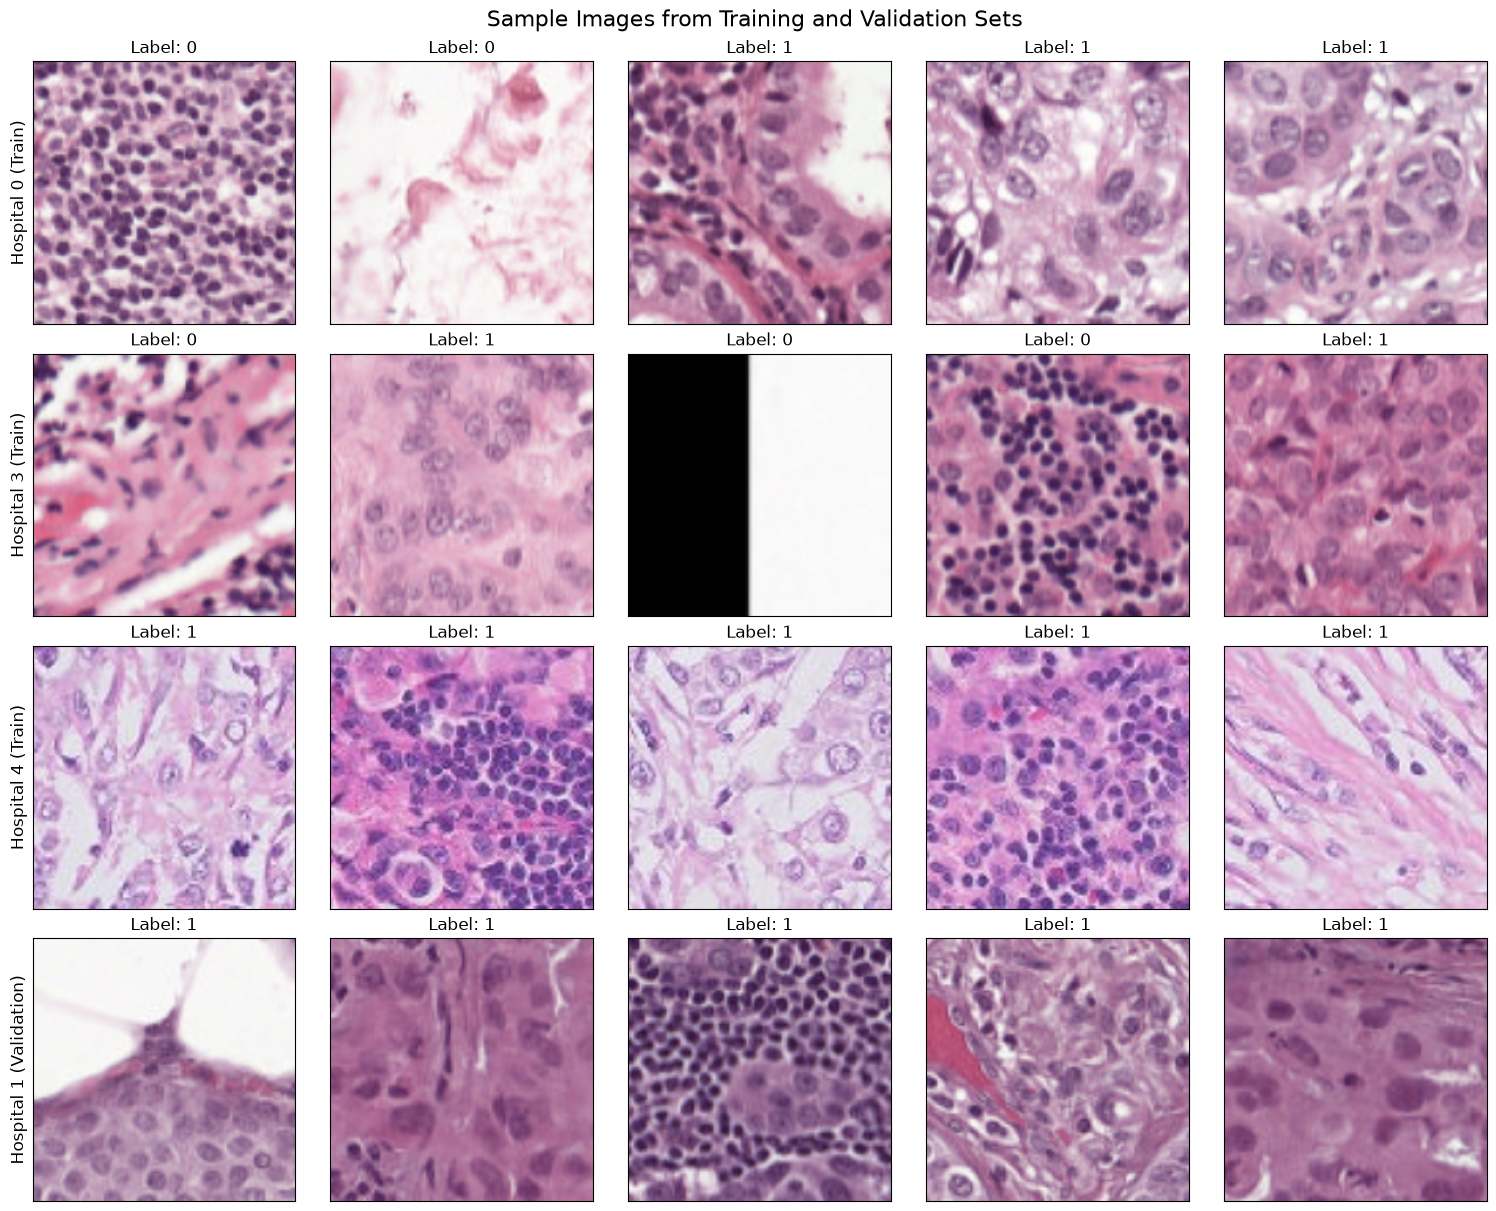

In [9]:
def denormalize(image: torch.Tensor) -> torch.Tensor:
    """Denormalizes an image tensor."""
    mean = torch.tensor([0.485, 0.456, 0.406], device=image.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=image.device).view(3, 1, 1)
    return (image * std + mean).permute(1, 2, 0)

n = 5

train_hospitals = torch.unique(train_data.metadata_array[:, 0])
val_hospitals = torch.unique(val_data.metadata_array[:, 0])

n_hospitals = len(train_hospitals) + len(val_hospitals)

fig, axes = plt.subplots(n_hospitals, n, figsize=(n * 3, n_hospitals * 3), constrained_layout=True)
for i, hospital in enumerate(train_hospitals):
    hospital_indices = torch.where(train_data.metadata_array[:, 0] == hospital)[0]
    selected_indices = np.random.choice(hospital_indices, n, replace=False)

    axes[i, 0].set_ylabel(f"Hospital {hospital.item()} (Train)", fontsize=12)

    for j, idx in enumerate(selected_indices):
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks([])

        image, label, metadata= train_data[idx]
        axes[i, j].imshow(denormalize(image))  # Convert from (C, H, W) to (H, W, C)
        axes[i, j].set_title(f"Label: {label.item()}")

for i, hospital in enumerate(val_hospitals, start=len(train_hospitals)):
    hospital_indices = torch.where(val_data.metadata_array[:, 0] == hospital)[0]
    selected_indices = np.random.choice(hospital_indices, n, replace=False)

    axes[i, 0].set_ylabel(f"Hospital {hospital.item()} (Validation)", fontsize=12)

    for j, idx in enumerate(selected_indices):
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks([])

        image, label, metadata= val_data[idx]
        axes[i, j].imshow(denormalize(image))
        axes[i, j].set_title(f"Label: {label.item()}")

fig.suptitle("Sample Images from Training and Validation Sets", fontsize=16)

plt.show()


In [10]:
# Explore the dataset further, plot at least one more figure to compose your EDA.
# You can plot any figure you think will help you understand the dataset better. Examples include:
# - Distribution of labels across hospitals
# - Distribution of metadata features
# - Distribution of pixel intensities



In [11]:
import collections
import numpy as np

metadata_fields = dataset.metadata_fields
y_col_idx = metadata_fields.index('y') if 'y' in metadata_fields else metadata_fields.index('tumor')

# Avaliar a distribuição de classes em cada split do dataset
for split_name, split_data in [("Treino", train_data), ("Validação (ID)", val_data), ("Teste (OOD)", test_data)]:
    labels = split_data.y_array
    counter = collections.Counter(labels.numpy())
    total = len(labels)
    print(f"\nDistribuição de classes no split {split_name}:")
    for label, count in sorted(counter.items()):
        percent = (count / total) * 100
        class_name = "Tumor (1)" if label == 1 else "Normal (0)"
        print(f"  {class_name}: {count} amostras ({percent:.2f}%)")



Distribuição de classes no split Treino:
  Normal (0): 151046 amostras (49.94%)
  Tumor (1): 151390 amostras (50.06%)

Distribuição de classes no split Validação (ID):
  Normal (0): 17452 amostras (50.00%)
  Tumor (1): 17452 amostras (50.00%)

Distribuição de classes no split Teste (OOD):
  Normal (0): 42527 amostras (50.00%)
  Tumor (1): 42527 amostras (50.00%)


In [12]:
hosp_col_idx = metadata_fields.index('hospital')
# Amostras por hospital 
train_centers = train_data.metadata_array[:, hosp_col_idx].numpy()
center_counts = collections.Counter(train_centers)
total_train = len(train_centers)

print("\nDistribuição de amostras por Hospital no Treino:")
for center, count in sorted(center_counts.items()):
    percent = (count / total_train) * 100
    print(f"  Hospital {center}: {count} amostras ({percent:.2f}%)")



Distribuição de amostras por Hospital no Treino:
  Hospital 0: 53425 amostras (17.66%)
  Hospital 3: 116959 amostras (38.67%)
  Hospital 4: 132052 amostras (43.66%)



Porcentagem de classes (Normal vs Tumor) dentro de cada Hospital (Treino):
y                 0          1
hospital                      
0         49.950398  50.049602
3         49.962807  50.037193
4         49.922758  50.077242


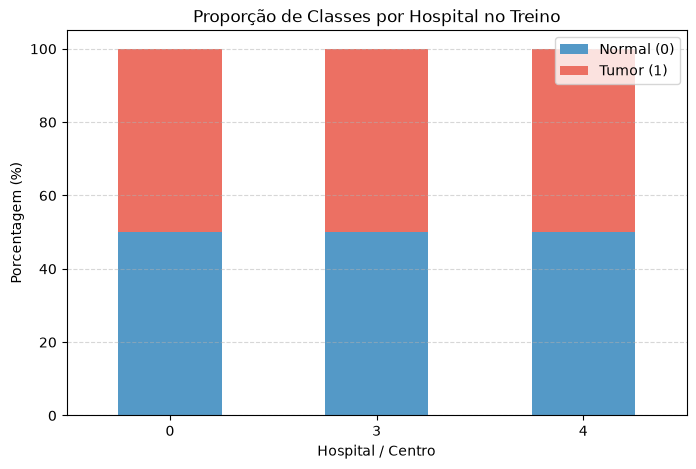

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Criar dataframe de treino para facilitar tabulação
df_train = pd.DataFrame(
    train_data.metadata_array.numpy(), 
    columns=metadata_fields
)

hosp_col_name = metadata_fields[hosp_col_idx]
y_col_name = metadata_fields[y_col_idx]

# Tabela cruzada normalizada por hospital
cross_tab = pd.crosstab(df_train[hosp_col_name], df_train[y_col_name], normalize='index') * 100
print("\nPorcentagem de classes (Normal vs Tumor) dentro de cada Hospital (Treino):")
print(cross_tab)

# Plotar gráfico de barras empilhadas
cross_tab.plot(kind='bar', stacked=True, color=['#5499C7', '#EC7063'], figsize=(8, 5))
plt.title("Proporção de Classes por Hospital no Treino")
plt.ylabel("Porcentagem (%)")
plt.xlabel("Hospital / Centro")
plt.legend(["Normal (0)", "Tumor (1)"])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


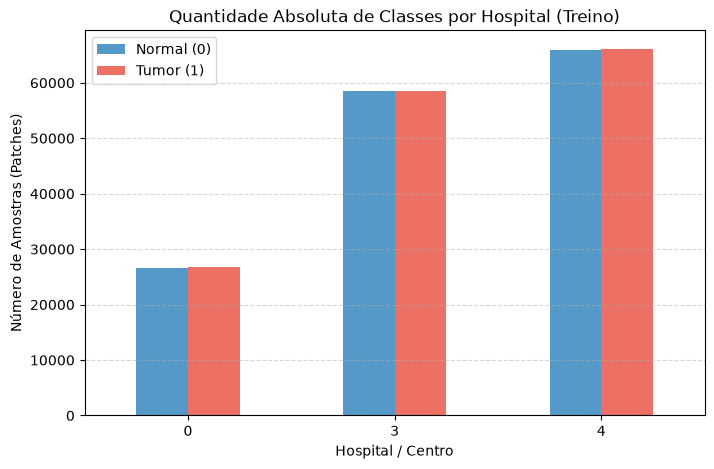

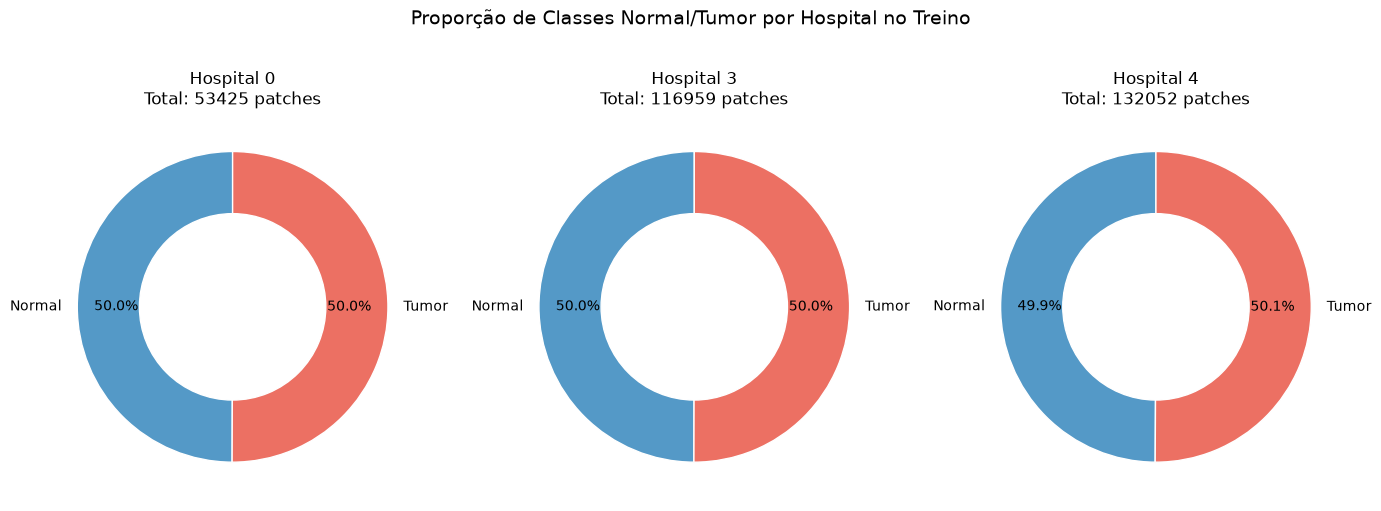

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Identificar dinamicamente as colunas de hospital e classe
metadata_fields = dataset.metadata_fields
hosp_col_idx = metadata_fields.index('hospital')
y_col_idx = metadata_fields.index('y') if 'y' in metadata_fields else metadata_fields.index('tumor')

hosp_col_name = metadata_fields[hosp_col_idx]
y_col_name = metadata_fields[y_col_idx]

# Criar dataframe de treino
df_train = pd.DataFrame(
    train_data.metadata_array.numpy(), 
    columns=metadata_fields
)

# Tabela cruzada de contagens absolutas (sem normalizar)
cross_tab_counts = pd.crosstab(df_train[hosp_col_name], df_train[y_col_name])

# ----------------- ALTERNATIVA 1: BARRAS LADO A LADO -----------------
cross_tab_counts.plot(kind='bar', stacked=False, color=['#5499C7', '#EC7063'], figsize=(8, 5))
plt.title("Quantidade Absoluta de Classes por Hospital (Treino)")
plt.ylabel("Número de Amostras (Patches)")
plt.xlabel("Hospital / Centro")
plt.legend(["Normal (0)", "Tumor (1)"])
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# ----------------- ALTERNATIVA 2: GRÁFICOS DE ROSCA -----------------
fig, axes = plt.subplots(1, len(cross_tab_counts), figsize=(14, 5))
for i, (center_id, row) in enumerate(cross_tab_counts.iterrows()):
    ax = axes[i]
    ax.pie(row, labels=["Normal", "Tumor"], colors=['#5499C7', '#EC7063'], 
           autopct='%1.1f%%', startangle=90, pctdistance=0.75,
           wedgeprops=dict(width=0.4, edgecolor='w'))
    ax.set_title(f"Hospital {center_id}\nTotal: {row.sum()} patches")
    
plt.suptitle("Proporção de Classes Normal/Tumor por Hospital no Treino", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


In [15]:
slide_col_idx = metadata_fields.index('slide')

for split_name, split_data in [("Treino", train_data), ("Validação (ID)", val_data), ("Teste (OOD)", test_data)]:
    unique_slides = np.unique(split_data.metadata_array[:, slide_col_idx].numpy())
    print(f"Split de {split_name}: {len(split_data)} patches extraídos de {len(unique_slides)} slides únicos.")


Split de Treino: 302436 patches extraídos de 30 slides únicos.
Split de Validação (ID): 34904 patches extraídos de 10 slides únicos.
Split de Teste (OOD): 85054 patches extraídos de 10 slides únicos.


Coletando amostras de imagens de cada hospital para análise de cores...


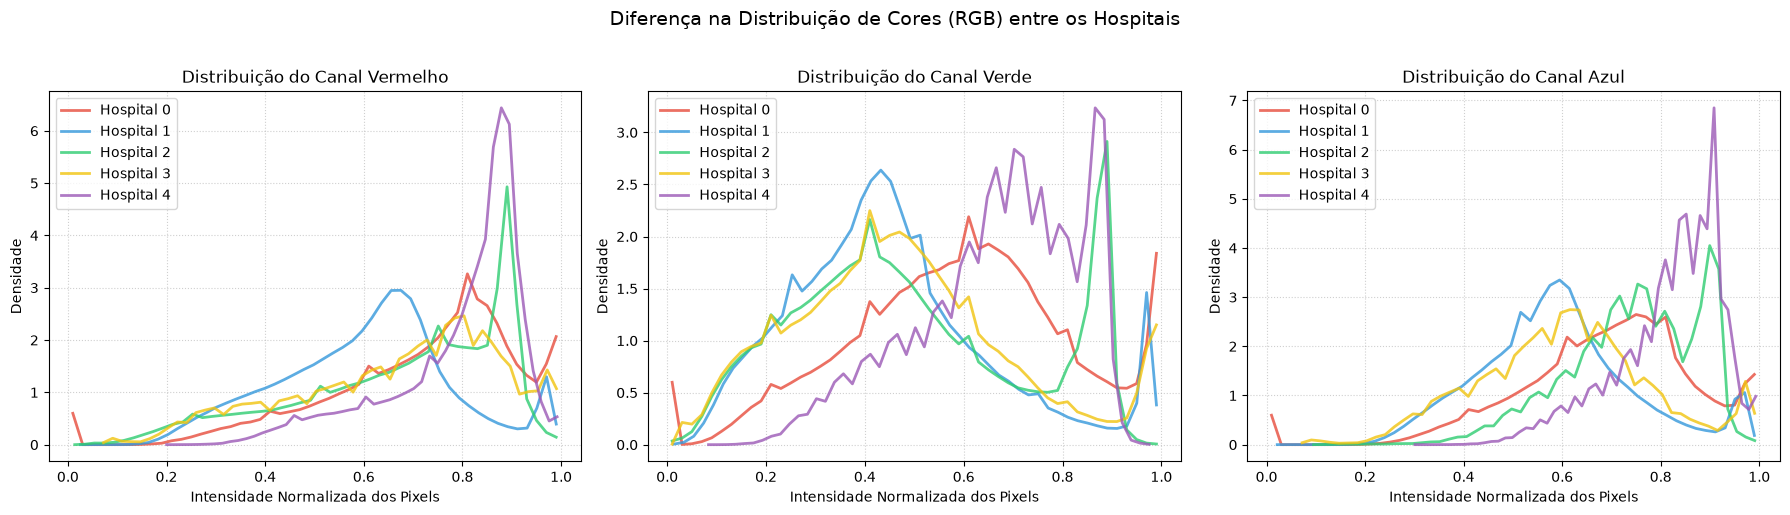

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import collections

def plot_color_distribution(dataset_obj, num_samples=100):
    hospitals = [0, 1, 2, 3, 4]
    hospital_images = {h: [] for h in hospitals}
    
    print("Coletando amostras de imagens de cada hospital para análise de cores...")
    
    # Embaralha os índices do dataset para pegar amostras aleatórias
    shuffled_indices = np.random.permutation(len(dataset_obj))
    
    for idx in shuffled_indices:
        # Pega a imagem (x) e os metadados
        x, _, metadata = dataset_obj[idx]
        
        # A coluna 0 dos metadados contém o hospital/centro
        hosp = int(metadata[0].item())
        
        if hosp in hospital_images and len(hospital_images[hosp]) < num_samples:
            # Tratamento dinâmico: se for Tensor PyTorch ou imagem PIL
            if hasattr(x, 'numpy'):
                img_np = x.numpy()
            else:
                # Se for PIL Image, convertemos para numpy e normalizamos para [0, 1]
                img_np = np.array(x) / 255.0
                if len(img_np.shape) == 3:
                    # Transpõe de (H, W, C) para (C, H, W)
                    img_np = img_np.transpose(2, 0, 1)
            
            hospital_images[hosp].append(img_np)
            
        # Para assim que tiver amostras suficientes de todos os hospitais
        if all(len(hospital_images[h]) >= num_samples for h in hospitals):
            break
            
    # Cria o gráfico
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    channels = ['Vermelho', 'Verde', 'Azul']
    colors_map = {0: '#E74C3C', 1: '#3498DB', 2: '#2ECC71', 3: '#F1C40F', 4: '#9B59B6'}
    
    for c_idx, ax in enumerate(axes):
        for hosp in hospitals:
            if len(hospital_images[hosp]) == 0:
                continue
            
            # Junta todos os pixels do canal correspondente para aquele hospital
            channel_vals = np.concatenate([img[c_idx].flatten() for img in hospital_images[hosp]])
            
            # Calcula o histograma (densidade de probabilidade)
            counts, bin_edges = np.histogram(channel_vals, bins=50, density=True)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            ax.plot(bin_centers, counts, label=f"Hospital {hosp}", color=colors_map[hosp], alpha=0.8, linewidth=2)
            
        ax.set_title(f'Distribuição do Canal {channels[c_idx]}')
        ax.set_xlabel('Intensidade Normalizada dos Pixels')
        ax.set_ylabel('Densidade')
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)
        
    plt.suptitle("Diferença na Distribuição de Cores (RGB) entre os Hospitais", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Chame a função passando o objeto principal 'dataset'
plot_color_distribution(dataset, num_samples=100)


> **Question.** (1.0 pts)
> 
> What are your findings? Describe the task, the characteristics you have found, possible challenges that you will encounter, and other initial hypothesis.
> 
> Do you think a neural network will be able to classify tumors and generalize to other hospitals?

Realizando uma análise exploratória inicial dos dados, percebemos algumas coisas relevantes. 

Primeiramente, buscamos analisar a distribuição de cada classe nos splits fornecidos, já que, caso houvesse um desbalanceamento notável, poderíamos criar hipóteses quanto a uma possível baixa capacidade de generalização e predição do modelo. O que notamos, entretanto, é que as classes estão bastantes balanceadas entre 'Normal' e 'Tumor', com quase 50% de cada para cada split. Isso pode ser um bom indicativo de que, caso haja overfitting ou uma baixa acurácia, talvez as explicações para isto não decorram de um possível desbalanceamento de classes no dataset. 
Além disso, também analisamos a mesma distribuição das classes para cada hospital presente no dataset (de modo análogo ao explicado anterior), e isso também demonstrou um equilíbrio. Portanto, tal balanceamento é um indicativo de que problemas de underfitting provavelmente não serão decorrentes de viéses de classe no dataset.

Um ponto importante de se mencionar, é que no dataset de treino, a quantidade de amostras decorrente dos hospitais 4 e 3 é significativamente maior que a quantidade do hospital 0 (sabemos que não há amostras do hospital 1 e nem 2 no treino). Dessa forma, o modelo é exposto a mais variabilidade e características de scanner dos hospitais 3 e 4. Isso nos levar a criar uma hipótese de uma possível baixa capacidade de generalização, em especial nas amostras dos hospitais 0, 1 e 2, na hora que formos testar o modelo. 

Por fim, também estudamos o comportamento das cores dos pixels nas amostras de cada hospital. Já que isso pode ser um comportamento relevante na hora de avaliarmos a generalização do modelo (que pode focar em 'decorar' comportamentos de cor nas amostras de determinado hospital para tentar fazer a predição, mas que na verdade refletem as diferenças sistemáticas nos modos de coleta). Existem, então, deslocamentos de pico e variações no formato das curvas de densidade entre os hospitais de treino (0, 3, 4) e os de validação (1) e teste (2). 

Portanto, com essa análise inicial, um desafio que esperamos encontrar estará justamente na mudança dos domínios. Quando formos validar e testar o modelo (em hospitais diferentes dos presentes no treino), esperamos que haja certa queda de desempenho e performance. Isso porque, a rede neural pode decorar atalhos relacionados aos perfis de cor das amostras de cada centro, que refletem mais diferenças na coleta do que na identificação dos tumores propriamente.

A quantidade de dados e o balanceamento percebido indica que uma rede neural provavelmente conseguirá classificar com boa acurácia nos hospitais já vistos (ID). Entretanto, quanto a generalização para os hospitais OOD espera-se que o modelo encontre dificuldades.

---

## Experiment 1: Transfer Model (Baseline)

[ResNet-18](https://arxiv.org/abs/1512.03385) is a convolutional neural network pretrained on ImageNet, a large-scale dataset of natural images spanning 1,000 object categories.
It is one of the most widely used backbones in transfer-learning pipelines due to its representation capacity across a broad domain of images.
Although it is often treated as a generic feature extractor, its architecture embeds several structural assumptions about images, which become encoded in the learned weights.
When transferring the model to histopathology, it is not immediately clear which of these assumptions remain useful, which are irrelevant, and which may even be harmful.

> **Question:**
>
>What inductive biases does a pretrained ResNet-18 inherit from pretraining on ImageNet, and do they transfer to histopathology?

> **Hypothesis:** 
>
> A pretrained ResNet-18 encodes local visual structures via hierarchical convolutional filters that generalize beyond natural images.
> As a result, a **linear classifier** trained on top of *frozen* ResNet features (a linear probe) should achieve accuracy substantially above 50% on both ID validation and OOD test data, despite the large domain gap between natural and histopathology images.

> **Baseline:**
>
> Random chance is 50% accuracy for balanced binary classification.

In [17]:
from matplotlib import backend_bases
# Representation cached from the ResNet-18 backbone

backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
print(backbone.fc)
backbone.fc = nn.Identity()  # Remove the final classification layer to get features instead of predictions.


train_loader = get_train_loader("standard", train_data, batch_size=128, num_workers=4)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=4)

with torch.no_grad():
    backbone.eval()
    backbone.to(DEVICE)

    train_features = []
    train_labels = []
    for images, labels, _ in train_loader:
        images = images.to(DEVICE)
        features = backbone(images).cpu()
        train_features.append(features)
        train_labels.append(labels)

    val_features = []
    val_labels = []
    for images, labels, _ in val_loader:
        images = images.to(DEVICE)
        features = backbone(images).cpu()
        val_features.append(features)
        val_labels.append(labels)


resnet_train_dataset = TensorDataset(torch.cat(train_features), torch.cat(train_labels))
resnet_val_dataset = TensorDataset(torch.cat(val_features), torch.cat(val_labels))

Linear(in_features=512, out_features=1000, bias=True)


/Users/tainaalmeida/Documents/Documents/ml/Tarefa03/mc886_env/lib/python3.14/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/Users/tainaalmeida/Documents/Documents/ml/Tarefa03/mc886_env/lib/python3.14/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/Users/tainaalmeida/Documents/Documents/ml/Tarefa03/mc886_env/lib/python3.14/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/e

In [18]:
# DataLoader para dados de teste originais
test_loader_raw = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=4)

with torch.no_grad():
    backbone.eval()
    backbone.to(DEVICE)

    test_features = []
    test_labels = []
    for images, labels, _ in test_loader_raw:
        images = images.to(DEVICE)
        features = backbone(images).cpu()
        test_features.append(features)
        test_labels.append(labels)

resnet_test_dataset = TensorDataset(torch.cat(test_features), torch.cat(test_labels))
resnet_test_loader = DataLoader(resnet_test_dataset, batch_size=128, shuffle=False, num_workers=4)


/Users/tainaalmeida/Documents/Documents/ml/Tarefa03/mc886_env/lib/python3.14/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/Users/tainaalmeida/Documents/Documents/ml/Tarefa03/mc886_env/lib/python3.14/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/Users/tainaalmeida/Documents/Documents/ml/Tarefa03/mc886_env/lib/python3.14/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/e

In [19]:
# You can modify the following methods as you want.
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    n_epochs: int,
    val_loader: DataLoader = None  # Adicionado val_loader opcional
) -> dict[str, list[float]]:
    """Trains the model and returns the training history."""
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_auc": []
    }

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = len(train_loader)

        for batch, batch_data in enumerate(train_loader):
            # Resolve dinamicamente se o batch tem 2 ou 3 elementos
            if len(batch_data) == 3:
                inputs, labels, _ = batch_data
            else:
                inputs, labels = batch_data

            inputs, labels = inputs.to(DEVICE), labels.float().to(DEVICE).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * inputs.size(0)

            perc = (batch + 1) / n_batches
            print(f"Epoch {epoch + perc:.2f}/{n_epochs}, Batch Loss: {loss.item():.4f}", end="\r")

        epoch_loss /= len(train_loader.dataset)
        history["train_loss"].append(epoch_loss)

        # Se val_loader for fornecido, avalia ao final de cada epoch
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            all_labels = []
            all_probs = []
            
            with torch.no_grad():
                for batch_data in val_loader:
                    if len(batch_data) == 3: # por causa da passagem pela resnet (feature extraction)
                        inputs, labels, _ = batch_data
                    else:
                        inputs, labels = batch_data
                        
                    inputs, labels = inputs.to(DEVICE), labels.float().to(DEVICE).unsqueeze(1)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item() * inputs.size(0)
                    
                    probs = torch.sigmoid(outputs).cpu().numpy()
                    all_probs.extend(probs.flatten())
                    all_labels.extend(labels.cpu().numpy().flatten())
            
            val_loss /= len(val_loader.dataset)
            val_auc = float(roc_auc_score(all_labels, all_probs))
            val_acc = float(np.mean((np.array(all_probs) >= 0.5).astype(int) == np.array(all_labels)))
            
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            history["val_auc"].append(val_auc)
            
            print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")
        else:
            print(f"Epoch {epoch+1}/{n_epochs} | Train Loss: {epoch_loss:.4f}                            ")

    return history


def evaluate_model(model: nn.Module, data_loader: DataLoader) -> dict[str, float]:
    """Evaluates the model on the given data loader and returns the AUC-ROC score and Accuracy."""
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch_data in data_loader:
            if len(batch_data) == 3:
                inputs, labels, _ = batch_data
            else:
                inputs, labels = batch_data
                
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs.flatten())
            all_labels.extend(labels.numpy().flatten())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    auc_roc = float(roc_auc_score(all_labels, all_probs))
    accuracy = float(np.mean((all_probs >= 0.5).astype(int) == all_labels))

    return {
        "auc_roc": auc_roc,
        "accuracy": accuracy,
        "labels": all_labels,
        "probs": all_probs
    }


In [20]:
class LinearProbe(nn.Module):
    """Linear probe on top of the ResNet-18 backbone."""
    def __init__(self, input_dim: int, num_classes: int) -> None:
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)

In [21]:
from torch.nn import BCEWithLogitsLoss

train_loader = DataLoader(resnet_train_dataset, batch_size=128, shuffle=True, num_workers=4) # treino
val_loader = DataLoader(resnet_val_dataset, batch_size=128, shuffle=False, num_workers=4) # validacao

model = LinearProbe(input_dim=512, num_classes=1).to(DEVICE)

optimizer = optim.SGD(model.parameters(), lr=0.1)
criterion = BCEWithLogitsLoss()

history = train_model(model, train_loader, criterion, optimizer, n_epochs=5, val_loader=val_loader)


Epoch 1/5 | Train Loss: 0.1945 | Val Loss: 0.2944 | Val Acc: 0.8808 | Val AUC: 0.9508
Epoch 2/5 | Train Loss: 0.1556 | Val Loss: 0.3235 | Val Acc: 0.8763 | Val AUC: 0.9458
Epoch 3/5 | Train Loss: 0.1489 | Val Loss: 0.3598 | Val Acc: 0.8667 | Val AUC: 0.9444
Epoch 4/5 | Train Loss: 0.1458 | Val Loss: 0.3588 | Val Acc: 0.8680 | Val AUC: 0.9467
Epoch 5/5 | Train Loss: 0.1430 | Val Loss: 0.3311 | Val Acc: 0.8752 | Val AUC: 0.9466


In [22]:
# Evaluate the model on the validation set, and also visualize the training history (e.g., plot the loss curve).
# You can also plot additional figures to help you analyze the results. Examples include:
# - AUC-ROC curve
# - Confusion matrix
# - Use a dimensionality reduction technique (e.g., t-SNE, PCA) to visualize the ResNet learned representations.

In [23]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Avaliação no conjunto ID - Validação
val_results = evaluate_model(model, val_loader)
print(f"--- In-Distribution (Validação) ---")
print(f"ID Accuracy: {val_results['accuracy']:.4f}")
print(f"ID AUC-ROC:  {val_results['auc_roc']:.4f}\n")

# Avaliação no conjunto OOD - Teste
test_results = evaluate_model(model, resnet_test_loader)
print(f"--- Out-of-Distribution (Teste) ---")
print(f"OOD Accuracy: {test_results['accuracy']:.4f}")
print(f"OOD AUC-ROC:  {test_results['auc_roc']:.4f}\n")

# Cálculo do Gap ID-OOD
accuracy_gap = val_results['accuracy'] - test_results['accuracy']
auc_gap = val_results['auc_roc'] - test_results['auc_roc']
print(f"Gap de Acurácia (ID - OOD): {accuracy_gap:.4f}")
print(f"Gap de AUC-ROC (ID - OOD):  {auc_gap:.4f}")


--- In-Distribution (Validação) ---
ID Accuracy: 0.8752
ID AUC-ROC:  0.9466

--- Out-of-Distribution (Teste) ---
OOD Accuracy: 0.8848
OOD AUC-ROC:  0.9677

Gap de Acurácia (ID - OOD): -0.0096
Gap de AUC-ROC (ID - OOD):  -0.0211


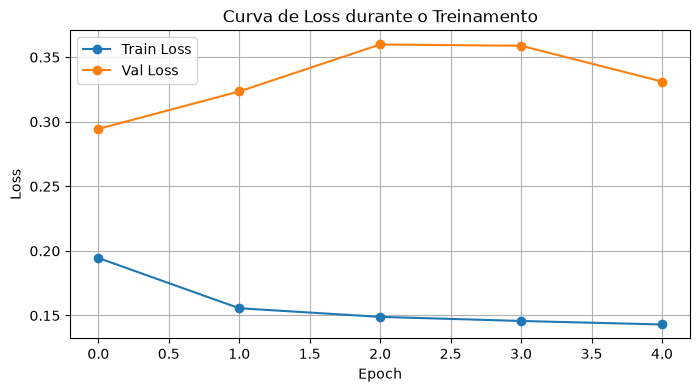

In [24]:
# Histório de treino
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train Loss", marker='o')
if "val_loss" in history and history["val_loss"]:
    plt.plot(history["val_loss"], label="Val Loss", marker='o')
plt.title("Curva de Loss durante o Treinamento")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


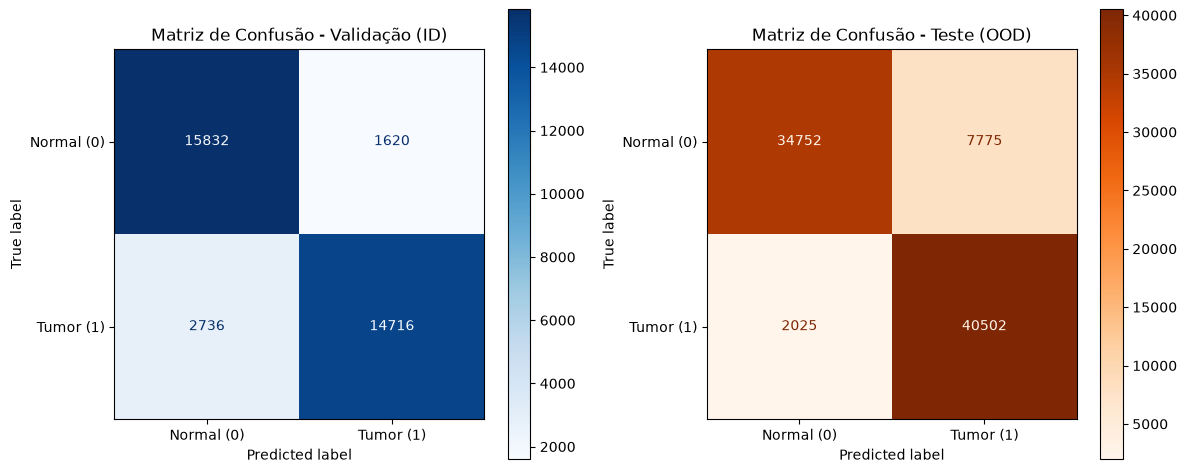

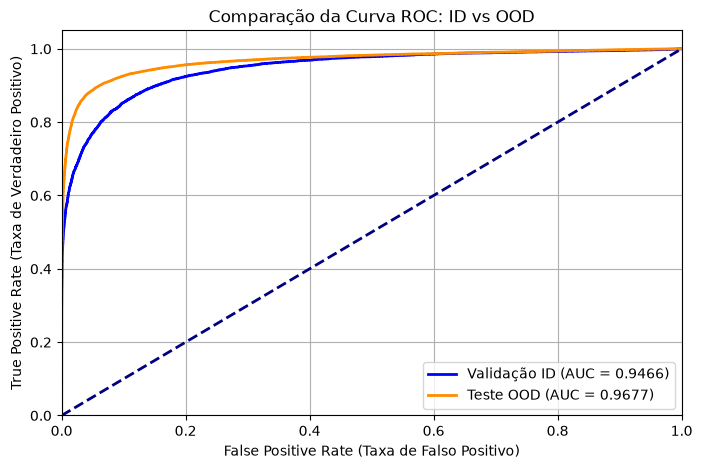

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

y_val_true = val_results["labels"]
y_val_probs = val_results["probs"]
y_val_preds = (y_val_probs >= 0.5).astype(int)

y_test_true = test_results["labels"]
y_test_probs = test_results["probs"]
y_test_preds = (y_test_probs >= 0.5).astype(int)


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de Validação (ID)
cm_val = confusion_matrix(y_val_true, y_val_preds)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Normal (0)', 'Tumor (1)'])
disp_val.plot(cmap=plt.cm.Blues, values_format='d', ax=ax[0])
ax[0].set_title('Matriz de Confusão - Validação (ID)')

# Matriz de Teste (OOD)
cm_test = confusion_matrix(y_test_true, y_test_preds)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Normal (0)', 'Tumor (1)'])
disp_test.plot(cmap=plt.cm.Oranges, values_format='d', ax=ax[1])
ax[1].set_title('Matriz de Confusão - Teste (OOD)')

plt.tight_layout()
plt.show()

# Curvas ROC
fpr_val, tpr_val, _ = roc_curve(y_val_true, y_val_probs)
roc_auc_val = auc(fpr_val, tpr_val)

fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_probs)
roc_auc_test = auc(fpr_test, tpr_test)

plt.figure(figsize=(8, 5))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validação ID (AUC = {roc_auc_val:.4f})')
plt.plot(fpr_test, tpr_test, color='darkorange', lw=2, label=f'Teste OOD (AUC = {roc_auc_test:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Taxa de Falso Positivo)')
plt.ylabel('True Positive Rate (Taxa de Verdadeiro Positivo)')
plt.title('Comparação da Curva ROC: ID vs OOD')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Executando t-SNE comparativo...


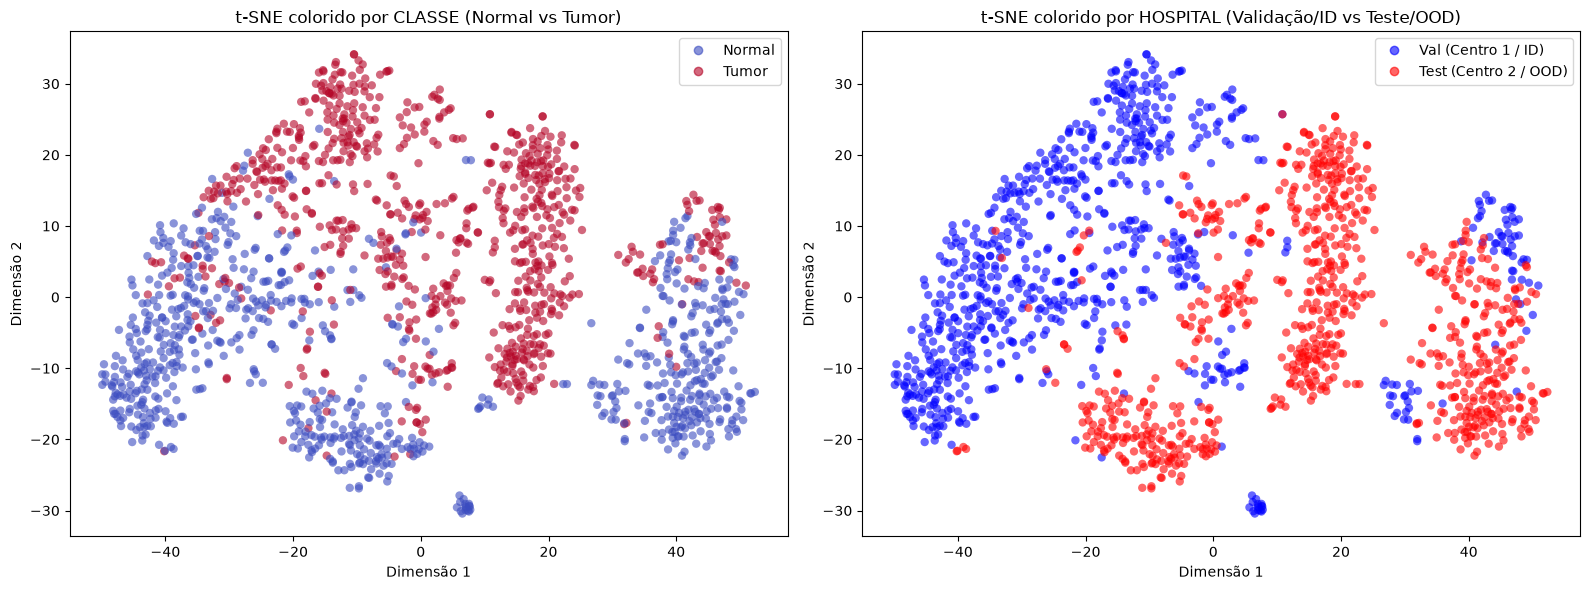

In [26]:
# 1. Pegar features e labels dos datasets de validação e teste
val_features = resnet_val_dataset.tensors[0].numpy()
val_labels = resnet_val_dataset.tensors[1].numpy()

test_features = resnet_test_dataset.tensors[0].numpy()
test_labels = resnet_test_dataset.tensors[1].numpy()

# 2. Amostrar 800 pontos de cada para não travar o t-SNE (total = 1600 pontos)
n_samples = 800
idx_val = np.random.choice(len(val_features), n_samples, replace=False)
idx_test = np.random.choice(len(test_features), n_samples, replace=False)

# Features combinadas
features_combined = np.vstack([val_features[idx_val], test_features[idx_test]])

# Labels de classe combinados (0: Normal, 1: Tumor)
classes_combined = np.concatenate([val_labels[idx_val], test_labels[idx_test]])

# Labels de domínio combinados (0: Validação/ID, 1: Teste/OOD)
domains_combined = np.concatenate([np.zeros(n_samples), np.ones(n_samples)])

# 3. Rodar t-SNE no conjunto combinado
print("Executando t-SNE comparativo...")
tsne = TSNE(n_components=2, random_state=seed, n_jobs=-1)
coords_tsne = tsne.fit_transform(features_combined)


# 4. PLOTAR
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Colorido por CLASSE (Normal vs Tumor)
# Mostra se as classes biológicas se misturam ou se separam
scatter_class = ax[0].scatter(coords_tsne[:, 0], coords_tsne[:, 1], c=classes_combined, cmap='coolwarm', alpha=0.6, edgecolors='none')
ax[0].set_title("t-SNE colorido por CLASSE (Normal vs Tumor)")
ax[0].set_xlabel("Dimensão 1")
ax[0].set_ylabel("Dimensão 2")
# Customizar legenda do plot de classes
handles, _ = scatter_class.legend_elements()
ax[0].legend(handles, ['Normal', 'Tumor'], loc="upper right")

# Plot 2: Colorido por DOMÍNIO (Validação/ID vs Teste/OOD)
# Mostra se os dados se agrupam pelo hospital (indício forte de viés de domínio)
scatter_dom = ax[1].scatter(coords_tsne[:, 0], coords_tsne[:, 1], c=domains_combined, cmap='bwr', alpha=0.6, edgecolors='none')
ax[1].set_title("t-SNE colorido por HOSPITAL (Validação/ID vs Teste/OOD)")
ax[1].set_xlabel("Dimensão 1")
ax[1].set_ylabel("Dimensão 2")
# Customizar legenda do plot de domínios
handles, _ = scatter_dom.legend_elements()
ax[1].legend(handles, ['Val (Centro 1 / ID)', 'Test (Centro 2 / OOD)'], loc="upper right")

plt.tight_layout()
plt.show()


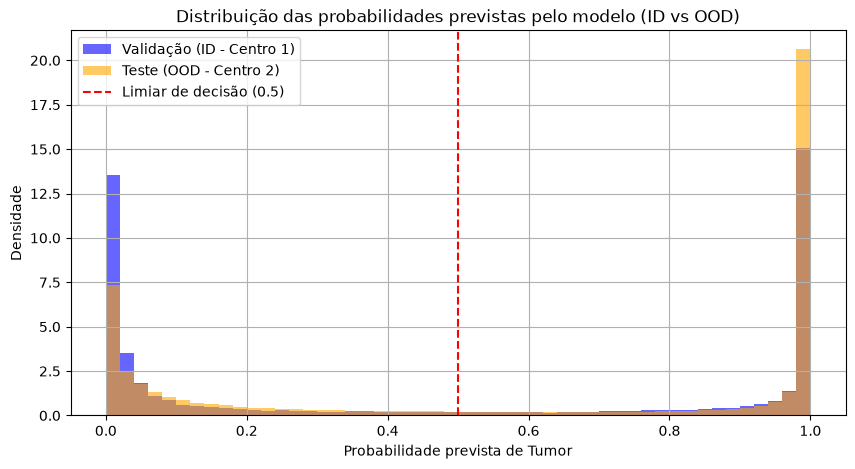

Probabilidade média (ID):  0.4761
Probabilidade média (OOD): 0.5838


In [27]:
plt.figure(figsize=(10, 5))

# Histograma das probabilidades previstas
plt.hist(y_val_probs, bins=50, alpha=0.6, label='Validação (ID - Centro 1)', color='blue', density=True)
plt.hist(y_test_probs, bins=50, alpha=0.6, label='Teste (OOD - Centro 2)', color='orange', density=True)

plt.axvline(x=0.5, color='red', linestyle='--', label='Limiar de decisão (0.5)')
plt.xlabel('Probabilidade prevista de Tumor')
plt.ylabel('Densidade')
plt.title('Distribuição das probabilidades previstas pelo modelo (ID vs OOD)')
plt.legend()
plt.grid(True)
plt.show()

# Complementando com médias
print(f"Probabilidade média (ID):  {y_val_probs.mean():.4f}")
print(f"Probabilidade média (OOD): {y_test_probs.mean():.4f}")


### Design justification

> **Question.** (1.0 pts)
> 
> Why changing only the last layer of the pretrained ResNet-18 is a reasonable baseline for this dataset?
>
> Explain what were the metrics that you used to test the hypothesis and why they help answering the question.

*YOUR ANSWER HERE*

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of using a frozen backbone. Address the following points:
> 
> Do the results support or contradict the hypothesis? Refer to specific numbers.
>
> What does the gap between metrics ID vs OOD imply about the representations?
>
> What limitations does the linear probe evaluation have when assessing the quality of the pretrained representations?
> Can we correctly attribute what is causing the observed performance?

*YOUR ANSWER HERE*

---

## Experiment 2: Is the CNN Structure Necessary?

ResNet is a convolutional architecture, meaning it builds in several strong assumptions: 
- local feature detection via small kernels
- spatial weight sharing
- hierarchical composition of features

These are not universal truths about image data, they are inductive biases that may or may not be useful for a given task.

A model with no spatial inductive bias, such as a multilayer perceptron (MLP) applied to flattened pixels, treats every pixel independently and must learn spatial relationships from data alone.
Comparing the two isolates the contribution of the convolutional inductive bias from all other factors.

This comparison also illustrates a central theme of this assignment: **raw parameter count does not determine generalization**.
As you will see, the MLP on 96×96×3 input has a first hidden layer alone with more parameters than the entire CNN, yet it may perform worse, demonstrating that inductive alignment with the data structure matters more than model capacity.

Note that, as we changed a lot of things when compared with the previous experiment, we cannot make a direct comparison, but we can see the performance on a baseline that already solves the problem.

> **Question:** Does the spatial inductive bias of a convolutional architecture improve generalization over a non-spatial model with comparable or greater parameter count?

### Hypothesis

> **Hypothesis.** (1.0 pts)
>
> *State a falsifiable hypothesis. Your hypothesis should make a concrete, directional prediction about the ID accuracy, OOD accuracy, and/or ID–OOD gap for the MLP vs SmallCNN. Refer to specific structural properties you expect to matter.*



# TODO: escrever direito as ideias

Alguns pensamentos sobre isso:
1. tumor pode aparecer em qualquer posição da imagem, e a invariancia à translacao da cnn, dada pelos pesos compartilhados espacialmente, faz com que possa ser identificado em diversas posiçoes
2. MLP nao tem esse vies, e precisa aprender essas relações do zero com cada pixel (muito caro e acredito que ineficiente)

Algumas previsoes:
1. acuracia do ID da cnn sera pelo menos tao boa quanto a da mlp
2. acuracia do ood da cnn vai ser bem melhor, se tratando de dados ainda nao vistos
3. suponho que o gap id e ood vai ser menor, pq a cnn vai deixar o modelo melhor generalizavel




In [ ]:
class MLP(nn.Module):
    """Fully connected network."""


    def __init__(self, input_size: int, hidden_dims: list[int], output_size: int) -> None:
        super().__init__()
        self.layer_sizes = [input_size] + hidden_dims + [output_size]
        self.weights = nn.ParameterList()
        self.biases = nn.ParameterList()
        
        torch.manual_seed(42)

        for i in range(len(self.layer_sizes) - 1):
            input_dim = self.layer_sizes[i]
            output_dim = self.layer_sizes[i+1]
            
            weight = nn.Parameter(torch.uniform_(torch.empty(input_dim, output_dim), -1, 1))
            bias = nn.Parameter(torch.zeros(1, output_dim))
            
            self.weights.append(weight)
            self.biases.append(bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1) 
        
        for i in range(len(self.weights)):
            x = torch.matmul(x, self.weights[i]) + self.biases[i] #multiplica a matriz pelos pesos e soma o bias
            
            if i < len(self.weights) - 1:
                x = torch.relu(x)
        return x


class SmallCNN(nn.Module):
    """Small convolutional network, spatial inductive bias."""

    def __init__(self, ...) -> None:
        super().__init__()
        # TODO: Build a small CNN with the following structure:
        #   3 convolutional blocks, each: Conv2d → BatchNorm2d → Activation → MaxPool2d(2)
        #   Choose any activation function you want (e.g., ReLU, LeakyReLU, GELU).
        #   The channel widths can be of your choice, but we recommend something like 3 → 32 → 64 → 128.
        #   The last block should be followed by: AdaptiveAvgPool2d(1) → Flatten → Linear.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Implement the forward pass through the CNN.

        return x


SyntaxError: invalid syntax (2902785370.py, line 4)

In [ ]:
# For this experiment, you can change the data transforms if you want.
# We recommend using smaller input sizes (e.g., the raw data is 96×96)
# for the MLP and SmallCNN, since they have fewer parameters than the ResNet-18
# and will overfit more easily on the full 224×224 images.
# You can use the same normalization as before, or recompute the mean and std
# on the smaller input size.

SIZE = 96

transform = transforms.Compose(
    [
        # You can uncomment the line below if you want to use a different input size.
        # transforms.Resize((SIZE, SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
    ]
)

train_data = dataset.get_subset("train", transform=transform)
val_data = dataset.get_subset("val", transform=transform)
test_data = dataset.get_subset("test", transform=transform)

In [ ]:
mlp_input_dim = SIZE * SIZE * 3  # 96 × 96 × 3 = 27,648

mlp = MLP(input_size=mlp_input_dim, hidden_dims=[512, 256])
cnn = SmallCNN()


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"MLP total parameters : {count_params(mlp):>12,}")
print(f"CNN total parameters : {count_params(cnn):>12,}")
print()
print("Note: both models receive the same 96×96×3 input and the same training procedure.")

In [ ]:
train_loader = get_train_loader("standard", train_data, batch_size=128, num_workers=4)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=4)

# Hint: Even though the models are different, you can use the same training loop and the same hyperparameters
# (e.g., learning rate, optimizer, number of epochs) for both models to make a fair comparison.
# You can also do hyperparameter tuning for each model separately if you want.

# The important thing is to ensure that both models are trained under similar conditions, or that both
# are given the opportunity to perform their best (e.g., by tuning hyperparameters separately).
# If your CNN, for example, performs much better than the MLP, but they were trained with very different setups,
# it is harder to convincingly argue that the CNN's superior performance is due to its architecture rather than the training procedure.

learning_rate = ...
n_epochs = ...
dropout = ...

In [ ]:
mlp_optimizer = ...
mlp_criterion = ...

train_mlp_history = train_model(mlp, train_loader, mlp_criterion, mlp_optimizer, n_epochs=n_epochs)

In [ ]:
cnn_optimizer = ...
cnn_criterion = ...

# CNN training might be slower than MLP training, so you can reduce the number of epochs for the CNN if needed.
train_cnn_history = train_model(cnn, train_loader, cnn_criterion, cnn_optimizer, n_epochs=n_epochs)

In [ ]:
# Plot the training history (e.g., loss curves) for both models, and evaluate their performance on the validation set.
# You can also plot additional figures to help you analyze the results. Examples include:
# - AUC-ROC curve
# - Confusion matrix
# - Use a dimensionality reduction technique (e.g., t-SNE, PCA) to visualize the learned representations of the models.
# - You can also visualize the learned filters of the CNN, or the activations of the intermediate layers, to gain insights into what the CNN is learning.
# - Or the first layer weights of the MLP, reshaped to 96×96 images, to see if it is learning any meaningful patterns.

### Design justification

> **Question.** (1.0 pts)
>
> Why comparing MLP vs SmallCNN (both trained from scratch on the same data) isolates the contribution of the convolutional inductive bias?
> 
> What aspect of the your implementation makes it an atomic ablation?

*YOUR ANSWER HERE*

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of using MLP vs CNN in generalization. Address the following points:
> 
> Do the results support or contradict your hypothesis? Refer to specific metric values.
>
> Compare the ID–OOD gap for MLP vs CNN. Which model generalizes better to the unseen center, and why might that be?
>
> The MLP has more parameters than the CNN, did this fact influenced the generalization aspect of the MLP?
>
> How do the from-scratch models compare to the frozen ResNet from Experiment 1?

*YOUR ANSWER HERE*

---

## Experiment 3: Are Colors a Required Feature?

A potential issue in the data is that, different hospitals use different techniques for collecting data.
One example of such change is how the stain intensity shift across hospital centers.

Because each center has a different scanner and staining protocol, the color distribution of a patch partially encodes which hospital it came from.
This creates a potential **spurious correlation**: a model trained on centers 0–2 may learn to use color as a predictive cue, even though color is determined by the imaging center rather than by tumor status.

Under center shift (training on centers 0–2, testing on center 4), a model that relies on color will encounter a new color distribution and may fail even if the morphological signal is present.

> **Question:** Does the previous CNN rely on color information to predict tumor status, and does removing color change the generalizaion gap?

### Hypothesis

> **Hypothesis.** (1.0 pts)
>
> *State a falsifiable hypothesis. Your hypothesis should predict the direction of the change in ID accuracy, OOD accuracy, and/or ID–OOD gap when switching from RGB to grayscale input. Relate your prediction to the color distribution visualization from the Data Exploration section.*

*YOUR ANSWER HERE*

In [ ]:
# Maintain the same configurations you set on the previous cells (e.g. input size, normalization, etc.) to
# isolate the effect of changing the data assumptions.

transform = transforms.Compose(
    [
        # Uncomment the line below if you want to use a different input size.
        # transforms.Resize((SIZE, SIZE)),
        transforms.Grayscale(num_output_channels=3),  # Convert to 3-channel grayscale to use the same architecture as before.
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

train_data = dataset.get_subset("train", transform=transform)
val_data = dataset.get_subset("val", transform=transform)
test_data = dataset.get_subset("test", transform=transform)

In [ ]:
# Your code here
# Train, evaluate and analyze.

### Design justification

> **Question.** (1.0 pts)
>
> Explain your experiment configuration, state what remained the same from the previous experiment, and what have changed.
>
> How does your experiment answer the question?

*YOUR ANSWER HERE*

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of removing the color feature. Address the following points:
> 
> Does removing color improve or degrade ID metrics? OOD metrics? Was this consistent with your hypothesis?
>
> Can we attribute the results uniquely to the color change?
>
> How does it connect with the Data exploration you conducted?

*YOUR ANSWER HERE*

---

## Model Selection: Choosing the final model

The three previous experiments provide evidence about what drives and what hinders generalization in this setting:

- **Experiment 1** established the baseline: a linear probe on frozen pretrained features achieves some performance, with a measurable ID–OOD gap.
- **Experiment 2** assessed whether spatial inductive bias matters.
- **Experiment 3** assessed whether color is a spurious or informative feature.

In this experiment you will use those observations to motivate a final model of your choice and test whether it generalizes for the test dataset.

You don't need to state a hypothesis, or justify your design here.
Experiment with different settings and suppositions until you converge with the best model that might well generalize.
You can use ResNet, or a network from scratch, just report the number of parameters on the final model and the time it took to
train.

> **Question**
>
> Based on the evidence from previous experiments, propose a deep neural network that might reduce the ID–OOD generalization gap.

In [ ]:
# TODO: Implement your final model (you can choose any architecture you want, including the ones you implemented before) and train it on the dataset.
# Some suggestions:
# - You can use the ResNet-18 backbone from Experiment 1 and fine-tune all (or the last N) layers instead of freezing them.
# - You can use the MLP or SmallCNN from Experiment 2 and increase their capacity (e.g., more layers, more hidden units, etc.).
# - You can change the data transforms (e.g., input size, normalization, data augmentation, etc.) to see if it improves the performance of the models.
# - You can use other loss functions (e.g., focal loss, dice loss, etc.) or optimization algorithms (e.g., AdamW, RMSProp, etc.).
# - A combination of the above suggestions (caution to not change too many things at once, or it will be harder to analyze the results and understand what caused the performance changes).

In [ ]:
# Evaluate your final model, analyze the results.
# Use the same evaluation metrics and plots you used in the previous experiments to analyze the performance of your final model.
# Now, you can also evaluate your final model on the test set, but make sure to only do this after you have finalized your model
# and analysis based on the validation set, to avoid overfitting to the test set.

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results for your final model.
> 
> What is the number of parameters of your model? Compare it with the size of the previous models and draw a link with the results.
>
> What was the training time? Did it take more or less time than the expected?
>
> How does the OOD performance connect with your changes in the data and model?
>
> If your results are positive, can you attribute for certain which aspect of your model mostly contributed for the increase in performance?
> 
> Conversely, if your results are negative (the modification were worse than the experiments), provide an alternative explanation that is consistent with the failure.

*YOUR ANSWER HERE*

---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written section (Hypothesis, Design, Discussion) are filled in.
- AI usage declaration and prompts are included, if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.